Import Dataset From Kaggle

In [1]:
import kagglehub
import os
import shutil

target_dir = "dataset"

if not os.path.exists(target_dir):
    print("Dataset folder not found. Downloading...")

    cache_path = kagglehub.dataset_download("divyam6969/chest-xray-pneumonia-dataset")
    print("Downloaded to:", cache_path)

    shutil.copytree(cache_path, target_dir)
    print("Dataset saved to:", target_dir)

else:
    print("Dataset already exists. Skipping download.")

Dataset folder not found. Downloading...


100%|██████████| 1.07G/1.07G [00:28<00:00, 40.8MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/divyam6969/chest-xray-pneumonia-dataset/versions/1
Dataset saved to: dataset


Check all image / distribution

Processed Train Images:
  NORMAL: 1341 images
  VIRAL: 1345 images
  BACTERIAL: 2530 images
Processed Test Images: 40 images


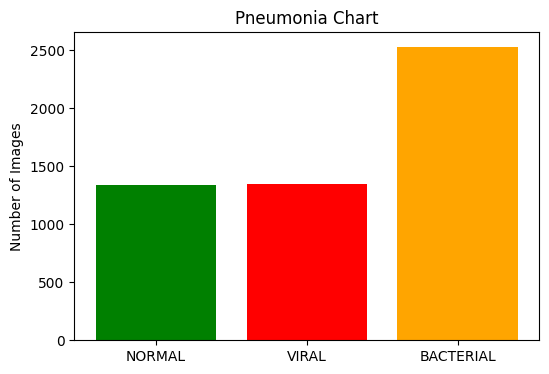

Found 5216 images belonging to 3 classes.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------ set up dir -------------------- #

train_dir = "/content/dataset/train"

test_dir = "/content/dataset/test"

# --------------- process / counting --------------- #

class_counts = {}

for cls in os.listdir(train_dir):
  cls_path = os.path.join(train_dir, cls)

  if os.path.isdir(cls_path):
    class_counts[cls] = len(os.listdir(cls_path))

# ------------- display number of image ------------ #

print("Processed Train Images:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")


test_images = len([img for img in os.listdir(test_dir)
                if img.lower().endswith(('jpg','jpeg','png'))])

print(f"Processed Test Images: {test_images} images")

# --------------------- chart -------------------- #

class_colors = {
    'NORMAL': 'green',
    'BACTERIAL': 'orange',
    'VIRAL': 'red'
}

bar_colors = [class_colors[cls] for cls in class_counts.keys()]

plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values(), color=bar_colors)
plt.title("Pneumonia Chart")
plt.ylabel("Number of Images")
plt.show()

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32
)


training + testing with the use of HOG + RBF SVM


Loading training data (PARALLEL)
Found class subdirectories: ['NORMAL', 'VIRAL', 'BACTERIAL']
Processing 5216 images in parallel...
Using 2 CPU cores


100%|██████████| 5216/5216 [00:54<00:00, 96.52it/s] 



Training set: 5216 samples
Feature vector size: 900

Loading test data (PARALLEL)
No subdirectories found. Parsing filenames...
Processing 40 images in parallel...
Using 2 CPU cores


100%|██████████| 40/40 [00:00<00:00, 72.26it/s]



Test set: 40 samples

Scaling features...
Scaling completed!
Scaling time: 0.08 seconds

CROSS-VALIDATION EVALUATION
Running 10-fold stratified cross-validation...
Computing cross-validation scores...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   56.0s finished



CROSS-VALIDATION RESULTS

📊 Accuracy Across 5 Folds:
   Fold 1: 80.75%
   Fold 2: 79.77%
   Fold 3: 78.81%
   Fold 4: 80.92%
   Fold 5: 82.07%

Mean CV Accuracy: 80.46% ± 1.10%

Training SVM (RBF)

Training final model...
[LibSVM]Training completed!
Training time: 12.22 seconds

Evaluation

Training Accuracy: 93.79%
Test Accuracy: 87.50%
Overfitting Gap: 6.29%

Test Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.95      1.00      0.98        20
      NORMAL       1.00      0.50      0.67        10
       VIRAL       0.71      1.00      0.83        10

    accuracy                           0.88        40
   macro avg       0.89      0.83      0.83        40
weighted avg       0.90      0.88      0.86        40



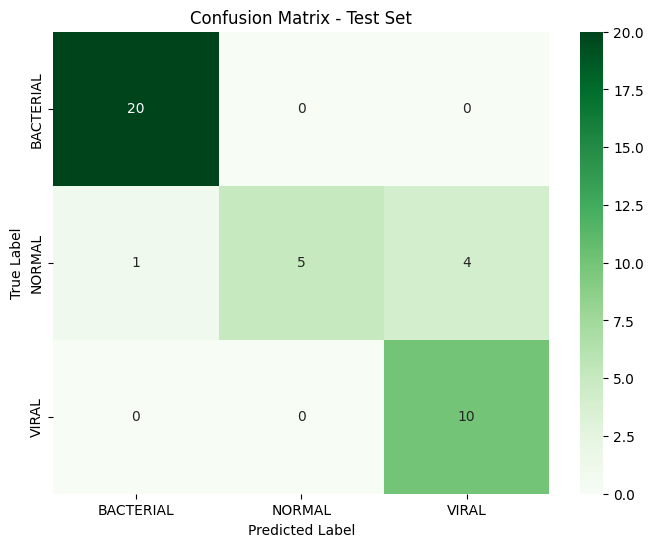


Saving model...

Summary
Training Samples: 5216
Test Samples: 40
Feature Dimensions: 900
Training Accuracy: 93.79%
Test Accuracy: 87.50%


In [3]:
# ==================== Import / from ==================== #

import os
import numpy as np
import cv2
import time
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from skimage.feature import hog
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed
import multiprocessing
from collections import Counter

# ==================== Configure directory ==================== #

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

IMG_SIZE = (96, 96)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

# ==================== Extract HOG features ==================== #

def extract_hog_features(image_path, visualize=False):
    """Extract HOG features"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = cv2.equalizeHist(img)

    if visualize:
        features, hog_image = hog(
            img,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            visualize=True,
            block_norm='L2-Hys'
        )
        return features, hog_image
    else:
        features = hog(
            img,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            visualize=False,
            block_norm='L2-Hys'
        )
        return features

def process_single_image(img_path, label):
    """Process one image"""
    try:
        features = extract_hog_features(img_path)
        if features is not None:
            return features, label
    except:
        pass
    return None, None

def load_dataset_parallel(data_dir, is_test=False):
    """Load images with PARALLEL processing"""
    image_paths = []
    labels = []

    subdirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    if subdirs:
        print(f"Found class subdirectories: {subdirs}")

        for class_name in subdirs:
            class_path = os.path.join(data_dir, class_name)

            for filename in os.listdir(class_path):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_path, filename)

                    if 'BACTERIAL' in class_name.upper():
                        label = 'BACTERIAL'
                    elif 'VIRAL' in class_name.upper():
                        label = 'VIRAL'
                    elif 'NORMAL' in class_name.upper():
                        label = 'NORMAL'
                    else:
                        label = class_name.upper()

                    image_paths.append(img_path)
                    labels.append(label)
    else:
        print("No subdirectories found. Parsing filenames...")

        for filename in os.listdir(data_dir):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(data_dir, filename)

                filename_upper = filename.upper()
                if 'NORMAL' in filename_upper:
                    label = 'NORMAL'
                elif 'BACTERIA' in filename_upper:
                    label = 'BACTERIAL'
                elif 'VIRUS' in filename_upper:
                    label = 'VIRAL'
                elif 'PNEUMONIA' in filename_upper:
                    label = 'BACTERIAL'
                else:
                    continue

                image_paths.append(img_path)
                labels.append(label)

    print(f"Processing {len(image_paths)} images in parallel...")
    num_cores = multiprocessing.cpu_count()
    print(f"Using {num_cores} CPU cores")

    results = Parallel(n_jobs=num_cores)(
        delayed(process_single_image)(path, label)
        for path, label in tqdm(zip(image_paths, labels), total=len(image_paths))
    )

# ======================= filtering ======================== #
    X = []
    y = []
    for features, label in results:
        if features is not None:
            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

# ====================== loading data ====================== #

print("\n" + "="*60)
print("Loading training data (PARALLEL)")
print("="*60)

X_train, y_train = load_dataset_parallel(train_dir)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Feature vector size: {X_train.shape[1]}")

print("\n" + "="*60)
print("Loading test data (PARALLEL)")
print("="*60)

X_test, y_test = load_dataset_parallel(test_dir, is_test=True)

print(f"\nTest set: {X_test.shape[0]} samples")

# ==================== scaling feature ==================== #

print("\nScaling features...")

start_time = time.time()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

end_time = time.time()
elapsed = end_time - start_time

print("Scaling completed!")
print(f"Scaling time: {elapsed:.2f} seconds")

# ==================== CROSS-VALIDATION ==================== #

print("\n" + "="*60)
print("CROSS-VALIDATION EVALUATION")
print("="*60)
print("Running 10-fold stratified cross-validation...")

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_for_cv = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=False,
    cache_size=2000,
    random_state=42
)

print("Computing cross-validation scores...")

cv_scores = cross_val_score(
    svm_for_cv,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

# Accuracy results
print(f"\n📊 Accuracy Across 5 Folds:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score*100:.2f}%")

print(f"\n{'='*60}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"{'='*60}")

# ======================= SVM (RBF) ======================= #

print("\n" + "="*60)
print("Training SVM (RBF)")
print("="*60)

svm_classifier = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=False,
    verbose=True,
    cache_size=2000,
    random_state=42
)

start_time = time.time()

print("\nTraining final model...")
svm_classifier.fit(X_train_scaled, y_train)

end_time = time.time()
elapsed = end_time - start_time

print("Training completed!")
print(f"Training time: {elapsed:.2f} seconds")

# ====================== evaluation ====================== #

print("\n" + "="*60)
print("Evaluation")
print("="*60)

y_train_pred = svm_classifier.predict(X_train_scaled)
y_test_pred = svm_classifier.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Overfitting Gap: {(train_accuracy - test_accuracy)*100:.2f}%")

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

# =================== Confusion Matrix ================== #
cm_test = confusion_matrix(y_test, y_test_pred)
classes_test = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes_test, yticklabels=classes_test)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ==================== saving model ==================== #

print("\nSaving model...")
joblib.dump(svm_classifier, "svm_model.joblib", compress=9)
joblib.dump(scaler, 'scaler.joblib')

print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print(f"Feature Dimensions: {X_train.shape[1]}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")